
# HW2 Notebook

> Shashank Singh
> 1235716991


## Task 1 - Titanic classification

1. preprocess the Titanic training data,
2. fine tune a decision tree and plot it,
3. report 5 fold cross validation accuracy for the fine tuned decision tree,
4. report 5 fold cross validation accuracy for the fine tuned random forest,
5. compare the two methods.


In [1]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier


In [2]:

def find_data_file(filename: str) -> Path:
    candidates = [
        Path(filename),
        Path('') / filename,
        Path('') / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Could not find {filename}. Put it in the notebook folder, data/, or ../content/."
    )

train_path = find_data_file('train.csv')
test_path = find_data_file('test.csv')

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print('train shape:', train_df.shape)
print('test shape :', test_df.shape)
train_df.head()


train shape: (891, 12)
test shape : (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



### Feature engineering and preprocessing

This pipeline keeps the work reproducible and clean:
- extract title from `Name`
- create `FamilySize`
- create `IsAlone`
- create `CabinKnown`
- drop high cardinality raw text columns after extracting useful signals
- impute missing values
- one hot encode categorical variables


In [3]:

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False).fillna('Unknown')
    rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev',
                   'Sir', 'Jonkheer', 'Dona']
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    df['CabinKnown'] = df['Cabin'].notna().astype(int)

    cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
    existing = [c for c in cols_to_drop if c in df.columns]
    return df.drop(columns=existing)

X = train_df.drop(columns=['Survived'])
y = train_df['Survived']
X_test_kaggle = test_df.copy()

feature_builder = FunctionTransformer(add_features)
X_engineered = add_features(X)

categorical_features = X_engineered.select_dtypes(include=['object']).columns.tolist()
numeric_features = [c for c in X_engineered.columns if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_features),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('numeric features    :', numeric_features)
print('categorical features:', categorical_features)


numeric features    : ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'CabinKnown']
categorical features: ['Sex', 'Embarked', 'Title']


### Fine tune a decision tree

In [4]:

dt_pipeline = Pipeline([
    ('features', feature_builder),
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [3, 4, 5, 6, 7],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__ccp_alpha': [0.0, 0.001, 0.005],
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    refit=True,
)

dt_grid.fit(X, y)
print('best decision tree params:')
print(dt_grid.best_params_)
print('\nbest mean CV accuracy from grid search:', round(dt_grid.best_score_, 4))

best decision tree params:
{'classifier__ccp_alpha': 0.0, 'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2}

best mean CV accuracy from grid search: 0.8227


In [5]:

best_dt = dt_grid.best_estimator_
dt_cv_scores = cross_val_score(best_dt, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print('decision tree fold accuracies:', np.round(dt_cv_scores, 4))
print('decision tree average CV accuracy:', round(dt_cv_scores.mean(), 4))


decision tree fold accuracies: [0.838  0.7978 0.7978 0.8371 0.8427]
decision tree average CV accuracy: 0.8227


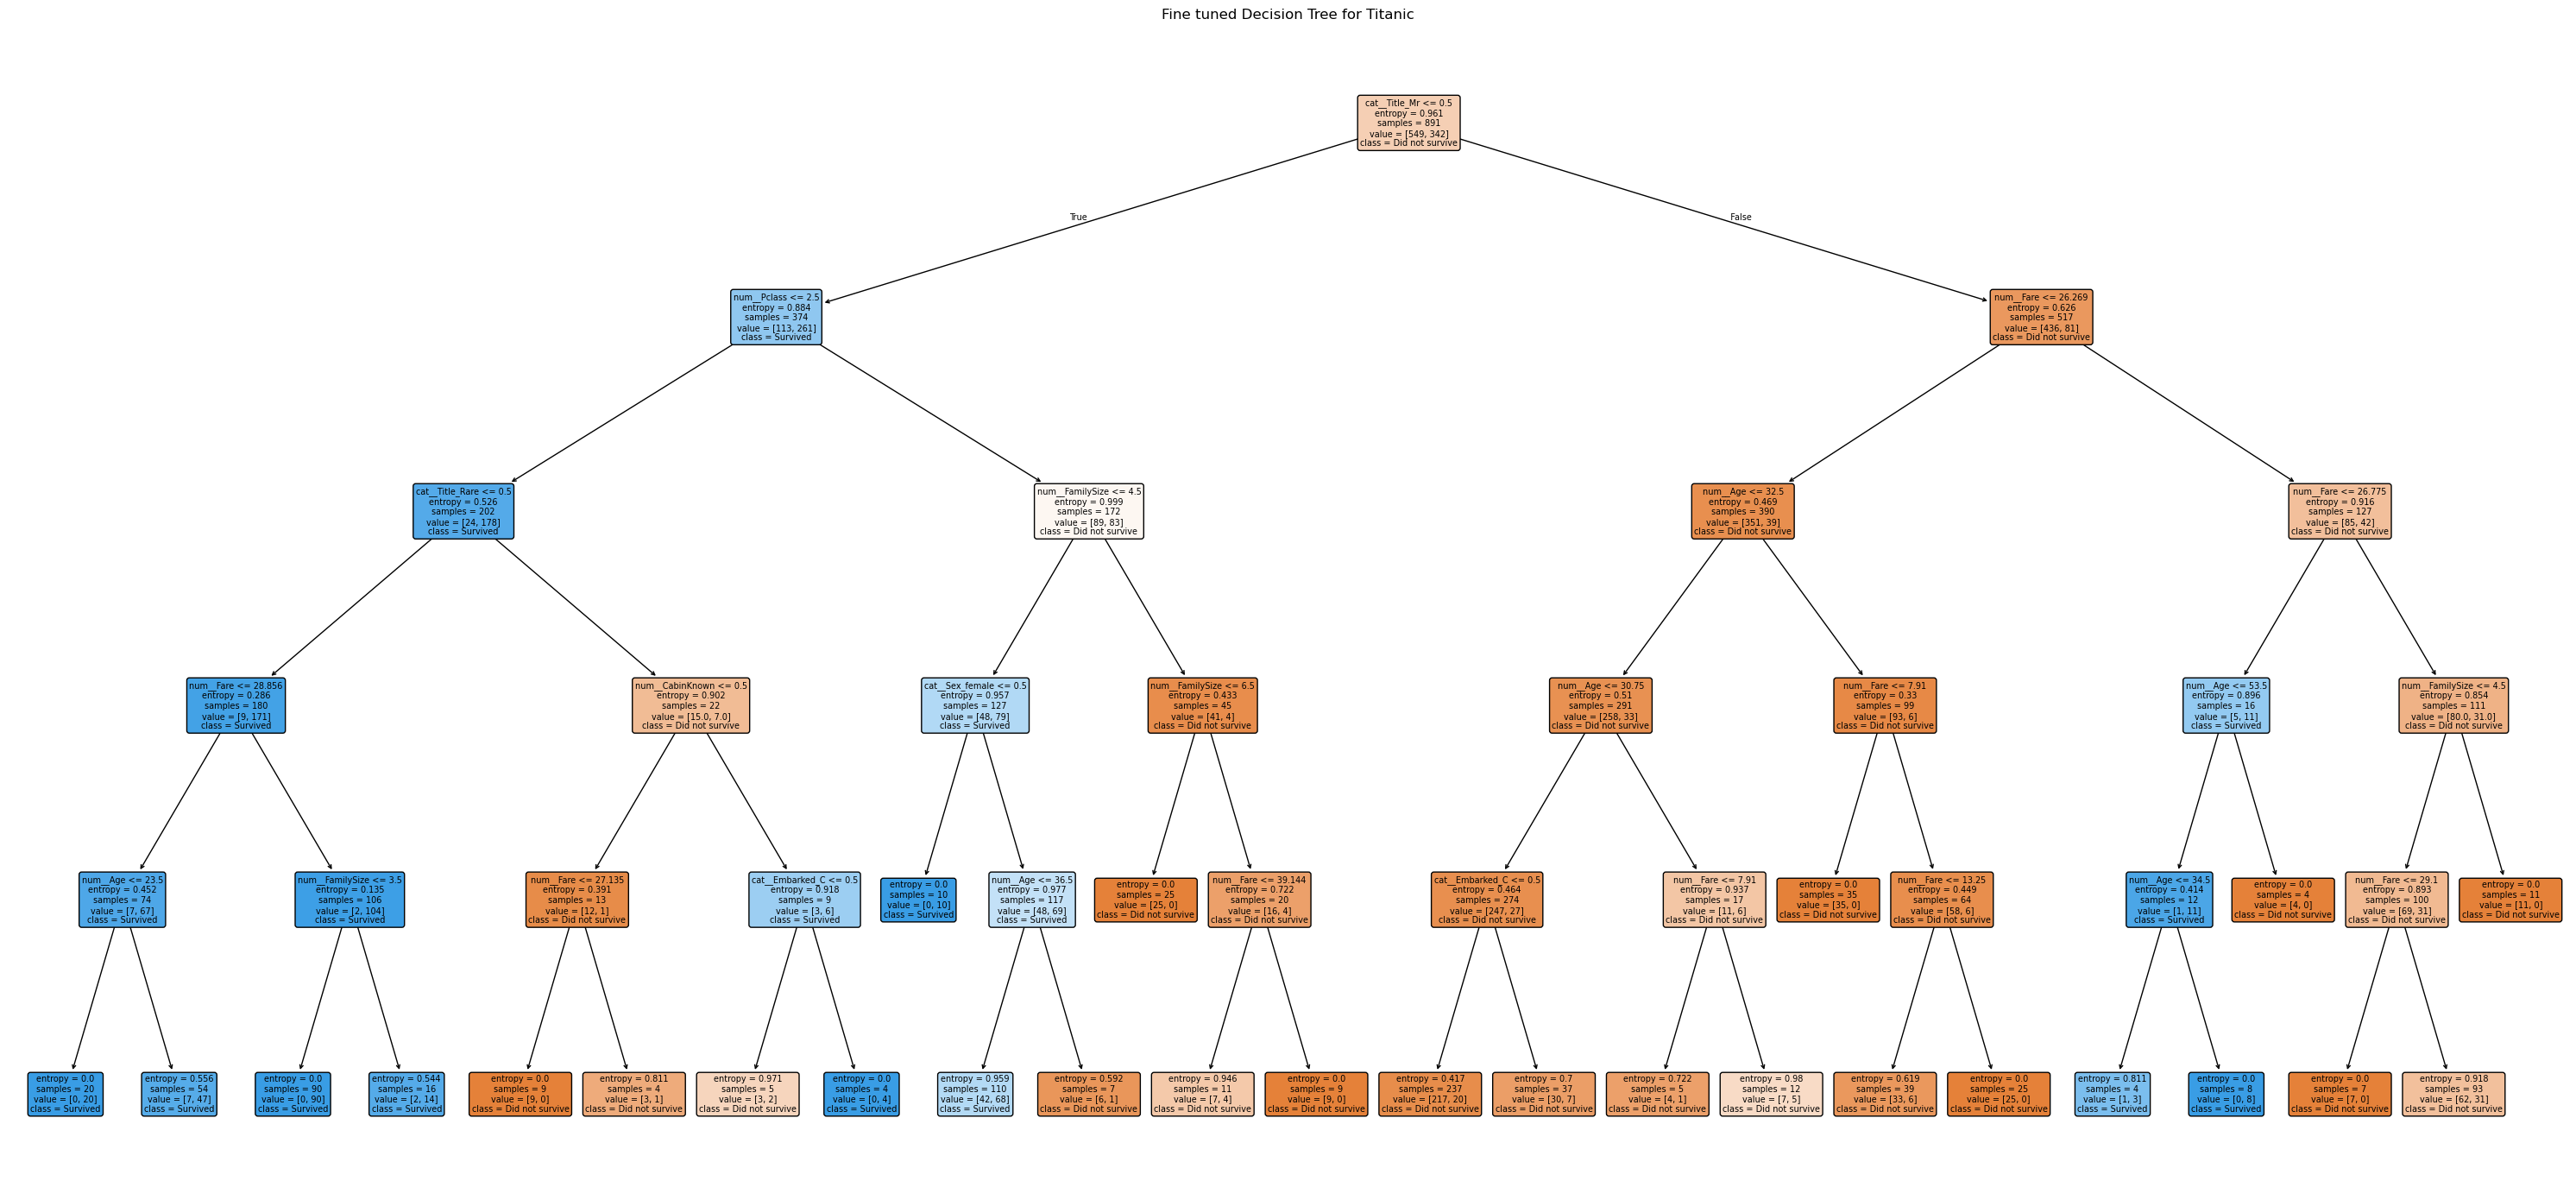

In [6]:

# Fit once on the full training data so we can visualize the tuned tree
best_dt.fit(X, y)

tree_preprocessor = best_dt.named_steps['preprocessor']
tree_model = best_dt.named_steps['classifier']
feature_names = tree_preprocessor.get_feature_names_out()

plt.figure(figsize=(30, 14))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=['Did not survive', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=7,
)
plt.title('Fine tuned Decision Tree for Titanic')
plt.tight_layout()
plt.savefig('titanic_decision_tree.png', dpi=200, bbox_inches='tight')
plt.show()


### Fine tune a random forest

In [7]:

rf_pipeline = Pipeline([
    ('features', feature_builder),
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'classifier__n_estimators': [200, 400],
    'classifier__max_depth': [5, 8, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': ['sqrt', 'log2'],
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    refit=True,
)

rf_grid.fit(X, y)
print('best random forest params:')
print(rf_grid.best_params_)
print('\nbest mean CV accuracy from grid search:', round(rf_grid.best_score_, 4))

best random forest params:
{'classifier__max_depth': 8, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

best mean CV accuracy from grid search: 0.8384


In [8]:

best_rf = rf_grid.best_estimator_
rf_cv_scores = cross_val_score(best_rf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print('random forest fold accuracies:', np.round(rf_cv_scores, 4))
print('random forest average CV accuracy:', round(rf_cv_scores.mean(), 4))


random forest fold accuracies: [0.8603 0.8315 0.8202 0.8427 0.8371]
random forest average CV accuracy: 0.8384


In [9]:

comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Average 5 Fold CV Accuracy': [dt_cv_scores.mean(), rf_cv_scores.mean()]
}).sort_values(by='Average 5 Fold CV Accuracy', ascending=False)

comparison


,Model,Average 5 Fold CV Accuracy
1,Random Forest,0.838359
0,Decision Tree,0.822654



## Task 6 - SVM in transformed feature space

Use the feature map
\[
\phi(x_1, x_2) = (z_1, z_2) = (x_1, x_1x_2)
\]

The four points map as follows:
- `(-1, -1)` with class negative -> `(-1, 1)`
- `(-1,  1)` with class positive -> `(-1, -1)`
- `( 1, -1)` with class positive -> `( 1, -1)`
- `( 1,  1)` with class negative -> `( 1, 1)`

So in the transformed space:
- both positive points lie on the line `z_2 = -1`
- both negative points lie on the line `z_2 = 1`

The maximal margin separator is therefore the horizontal line
\[
z_2 = 0
\]
which is equivalent to
\[
x_1x_2 = 0
\]
in the mapped space.

The distance from `z_2 = 0` to either support line `z_2 = 1` or `z_2 = -1` is `1`, so the margin, using your lecture definition, is:

\[
oxed{1}
\]

If someone uses the full width between the two support lines, that width would be `2`, but your homework explicitly defines margin as the distance from the separating hyperplane to one support set, so the correct homework answer is **1**.


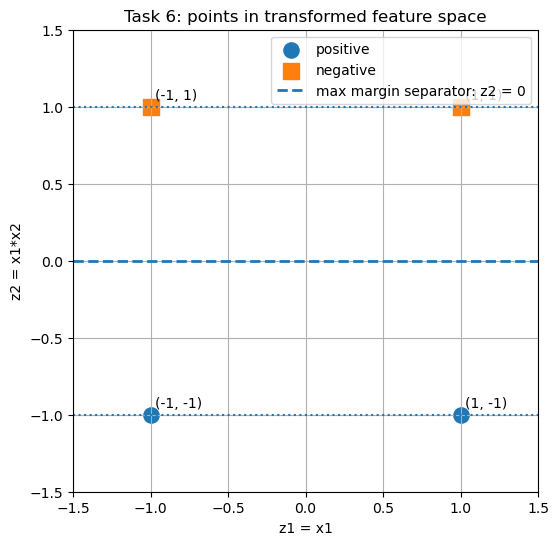

In [11]:

# Optional plot for Task 6
mapped_points = pd.DataFrame({
    'z1': [-1, -1, 1, 1],
    'z2': [1, -1, -1, 1],
    'label': ['negative', 'positive', 'positive', 'negative']
})

fig, ax = plt.subplots(figsize=(6, 6))
for label, marker in [('positive', 'o'), ('negative', 's')]:
    subset = mapped_points[mapped_points['label'] == label]
    ax.scatter(subset['z1'], subset['z2'], label=label, marker=marker, s=120)

ax.axhline(0, linestyle='--', linewidth=2, label='max margin separator: z2 = 0')
ax.axhline(1, linestyle=':', linewidth=1.5)
ax.axhline(-1, linestyle=':', linewidth=1.5)

for _, row in mapped_points.iterrows():
    ax.annotate(f"({row['z1']}, {row['z2']})", (row['z1'] + 0.03, row['z2'] + 0.05))

ax.set_xlabel('z1 = x1')
ax.set_ylabel('z2 = x1*x2')
ax.set_title('Task 6: points in transformed feature space')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.legend()
ax.grid(True)
plt.show()
